# Zarr Creation & Performance Benchmarking

## Introduction

To create the data cube in virtualzarr format using the outputs from `gdal` and `cdo`.

### Key Objectives:

1. **Visualize outputs** from CDO and GDAL preprocessing pipelines
2. **Create Zarr stores** from preprocessed netCDF files
3. **Benchmark performance** comparing:
   - NetCDF (original format)
   - Zarr (converted format)
4. **Measure metrics**: Load time, memory usage, file size, and query performance




In [1]:
# Import Required Libraries (NetCDF -> Zarr workflow only)

# Fix matplotlib backend issue from environment
import os
if "MPLBACKEND" in os.environ:
    del os.environ["MPLBACKEND"]

# Core analysis
import xarray as xr
import numpy as np
import pandas as pd

# Zarr + performance
import zarr
import time
import psutil
import gc

import lexcube

# Optional NetCDF backend import (some environments may not have it)
try:
    import netCDF4  # noqa: F401
except Exception as e:
    print(f"Note: netCDF4 import failed: {e}")

# Visualization
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib import rcParams

# File & system ops
import glob
import json
from pathlib import Path
from datetime import datetime

# Environment knobs
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# Warnings & logging
import warnings
warnings.filterwarnings("ignore")

# Configure matplotlib defaults
rcParams["figure.figsize"] = (14, 8)
rcParams["font.size"] = 10
rcParams["axes.labelsize"] = 11
rcParams["axes.titlesize"] = 12
rcParams["xtick.labelsize"] = 9
rcParams["ytick.labelsize"] = 9
rcParams["legend.fontsize"] = 10
rcParams["figure.titlesize"] = 14

print("Imports OK")
print(f"  - xarray: {xr.__version__}")
print(f"  - numpy:  {np.__version__}")
print(f"  - pandas: {pd.__version__}")
print(f"  - zarr:   {zarr.__version__}")

Imports OK
  - xarray: 2025.11.0
  - numpy:  2.4.2
  - pandas: 3.0.0
  - zarr:   3.1.5


## Notebook Configuration

Before running the analysis, ensure you have the following dependencies installed:

```bash
pip install xarray zarr pandas matplotlib psutil netCDF4
```

This notebook uses data outputs from the CDO and GDAL preprocessing pipelines located in:
- `../outputs/cdo_output/` - CDO processed netCDF files
- `../outputs/gdal_output/` - GDAL processed netCDF files
- `../outputs/zarr_outputs/` - Generated Zarr stores (created by this notebook)


In [ ]:
### 1. Define paths to CDO and GDAL outputs

# Setup directory paths
outputs_dir = "../outputs"
cdo_output_dir, gdal_output_dir = f"{outputs_dir}/cdo_output", f"{outputs_dir}/gdal_output"

# Define subdirectories
paths = {
    'cdo_metref': f"{cdo_output_dir}/metref",
    'cdo_rzsm': f"{cdo_output_dir}/rzsm",
    'gdal_metref': f"{gdal_output_dir}/metref",
    'gdal_sm': f"{gdal_output_dir}/rzsm"
}

# Find all files with corrected glob patterns
cdo_metref_files = sorted(glob.glob(f"{paths['cdo_metref']}/**/*.nc", recursive=True))
cdo_rzsm_files = sorted(glob.glob(f"{paths['cdo_rzsm']}/**/*.nc", recursive=True))
gdal_metref_files = sorted(glob.glob(f"{paths['gdal_metref']}/**/METREF/*.nc", recursive=True))

# GDAL SM files organized by variable folders (var40, var41, var42, var43)
gdal_sm_files = {}
for var_folder in ['var40', 'var41', 'var42', 'var43']:
    var_path = f"{paths['gdal_sm']}/**/{var_folder}/*.nc"
    files = sorted(glob.glob(var_path, recursive=True))
    if files:
        gdal_sm_files[var_folder] = files

# Print summary
print(f"CDO Output: {cdo_output_dir}\nGDAL Output: {gdal_output_dir}")
print(f"\nCDO METREF: {len(cdo_metref_files)} files | CDO RZSM: {len(cdo_rzsm_files)} files")
print(f"GDAL METREF: {len(gdal_metref_files)} files")
print(f"GDAL SM variables found: {list(gdal_sm_files.keys())}")
for var, files in gdal_sm_files.items():
    print(f"  {var}: {len(files)} files")


In [ ]:
# Configure input NetCDF directory (CDO output example)

store_path = Path("/home/kzakir/dvcube/test/outputs/gdal_output/metref/2010/01").resolve()
assert store_path.exists(), f"Missing input folder: {store_path}"

# Collect NetCDF files
all_files = sorted(glob.glob(str(store_path / "**" / "*.nc"), recursive=True))
print(f"Found {len(all_files)} NetCDF files under {store_path}")
assert len(all_files) > 0, "No .nc files found"

# Preview first file path
print("First file:", all_files[0])

In [ ]:
# Open multiple files with xarray

# If you get backend errors with netCDF4, switch to engine="h5netcdf" here too.
ds_nc = xr.open_mfdataset(
    all_files,
    combine="nested",
    concat_dim="time"
)

ds_nc

## Make Zarr format from the combine files

In [ ]:
# Write combined dataset directly to Zarr

import shutil

zarr_store_path = Path("../outputs/zarr_outputs/metref_combined_xarray_gdal.zarr").resolve()
zarr_store_path.parent.mkdir(parents=True, exist_ok=True)
if zarr_store_path.exists():
    shutil.rmtree(zarr_store_path)

t0 = time.time()

# 1) Chunk the combined dataset
chunk_plan = {"time": 1}
for dim in ["lat", "latitude", "y"]:
    if dim in ds_nc.dims:
        chunk_plan[dim] = 256
for dim in ["lon", "longitude", "x"]:
    if dim in ds_nc.dims:
        chunk_plan[dim] = 256

ds_chunked = ds_nc.chunk(chunk_plan)

# 2) Write to Zarr
ds_chunked.to_zarr(zarr_store_path, mode="w", consolidated=True)

dt = time.time() - t0
print(f"✓ Wrote Zarr store: {zarr_store_path}")
print(f"  - wall time: {dt:.2f}s")

In [ ]:
# 3) Reopen with xr.open_zarr and read a sample (sanity check)
zarr_store_path = Path("../outputs/zarr_outputs/metref_combined_xarray.zarr").resolve()

ds_z = xr.open_zarr(zarr_store_path, consolidated=True)
print("\nZarr dataset:")
print(ds_z)

varname = "METREF" if "METREF" in ds_z.data_vars else list(ds_z.data_vars)[0]
print(f"\nUsing variable: {varname}")

# Try scalar at (0,0,0)
scalar_indexers = {"time": 0}
if "lat" in ds_z.dims:
    scalar_indexers["lat"] = 0
if "lon" in ds_z.dims:
    scalar_indexers["lon"] = 0

val = ds_z[varname].isel(**scalar_indexers).load()
print(f"Scalar at (time=0, lat=0, lon=0): {float(val.values) if np.ndim(val.values) == 0 else val.values}")

# # Try a small tile to see if there are valid values elsewhere
# print("\n--- Reading a 10x10 tile (time=0, lat=100:110, lon=100:110) ---")
# try:
#     tile_indexers = {"time": 0}
#     if "lat" in ds_z.dims:
#         tile_indexers["lat"] = slice(100, 110)
#     if "lon" in ds_z.dims:
#         tile_indexers["lon"] = slice(100, 110)
    
#     tile = ds_z[varname].isel(**tile_indexers).load()
#     print(f"Tile shape: {tile.shape}")
#     print(f"Tile dtype: {tile.dtype}")
#     print(f"Tile min: {np.nanmin(tile.values):.4f}")
#     print(f"Tile max: {np.nanmax(tile.values):.4f}")
#     print(f"Valid (non-NaN) count: {np.sum(~np.isnan(tile.values))} / {tile.size}")
# except Exception as e:
#     print(f"Tile read failed: {e}")

# Data Testing

In [ ]:
import os
import xarray as xr
import rioxarray as rio
import zarr
import time
import psutil
import pandas as pd
import glob
import matplotlib.pyplot as plt
from dask.diagnostics import ProgressBar
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm as cm
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [4]:
da= xr.open_mfdataset("/data/dv-data/cdo_processed/NDVI/2024/01/*.nc")
da

<xarray.Dataset> Size: 90MB
Dimensions:  (time: 3, lat: 1001, lon: 7501)
Coordinates:
  * time     (time) datetime64[ns] 24B 2024-01-01 2024-01-11 2024-01-21
  * lat      (lat) float64 8kB 10.0 10.01 10.02 10.03 ... 19.97 19.98 19.99 20.0
  * lon      (lon) float64 60kB -20.0 -19.99 -19.98 -19.97 ... 54.98 54.99 55.0
Data variables:
    NDVI     (time, lat, lon) float32 90MB dask.array<chunksize=(1, 1, 7501), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.0.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.8
    source:       GDAL conversion from original IMG file sourced from LSAF EU...
    title:        NDVI Dekadal
    history:      Sun Apr 26 11:13:10 2026: cdo -L -f nc4 -z zip_4 -O -remapb...
    CDO:          Climate Data Operators version 2.0.4 (https://mpimet.mpg.de...

In [5]:
ndvi = da["NDVI"]
ndvi

<xarray.DataArray 'NDVI' (time: 3, lat: 1001, lon: 7501)> Size: 90MB
dask.array<concatenate, shape=(3, 1001, 7501), dtype=float32, chunksize=(1, 1, 7501), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 24B 2024-01-01 2024-01-11 2024-01-21
  * lat      (lat) float64 8kB 10.0 10.01 10.02 10.03 ... 19.97 19.98 19.99 20.0
  * lon      (lon) float64 60kB -20.0 -19.99 -19.98 -19.97 ... 54.98 54.99 55.0
Attributes:
    standard_name:  ndvi
    long_name:      Normalized Difference Vegetation Index
    units:          1

In [ ]:
%matplotlib inline
fig = plt.figure(figsize=(20, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
cmap1 = cm.Spectral_r

img = plt.pcolormesh(
    ndvi.lon,
    ndvi.lat,
    ndvi.isel(time=0),
    cmap=cmap1,
    transform=ccrs.PlateCarree(),
    vmin=-1,
    vmax=1,
    shading='auto'
)

ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=1)
ax.add_feature(cfeature.OCEAN, facecolor='lightcyan', linewidth=1)
ax.add_feature(cfeature.RIVERS, edgecolor='blue', linewidth=0.5)

# Logo
im = plt.imread('/home/kzakir/dvcube/test/zarr_cube/eumet_logo.png')
arr_im = OffsetImage(im, zoom=0.15)
ab = AnnotationBbox(
    arr_im,
    (0.06, 0.88),                  # axes fraction
    xycoords='axes fraction',
    frameon=True,
    bboxprops=dict(facecolor='white', edgecolor='grey', alpha=0.9)
)
ax.add_artist(ab)

# # Data source box
# ax.text(
#     0.015, 0.93, 'Data Source:',
#     transform=ax.transAxes,
#     fontsize=10,
#     color='black',
#     ha='left',
#     va='top',
#     bbox=dict(facecolor='white', edgecolor='grey', alpha=0.95, boxstyle='round,pad=0.25')
# )

# # Reference period box
# ax.text(
#     0.015, 0.04, 'Reference Period: 1991-2020',
#     transform=ax.transAxes,
#     fontsize=10,
#     color='black',
#     ha='left',
#     va='bottom',
#     bbox=dict(facecolor='white', edgecolor='grey', alpha=0.95, boxstyle='round,pad=0.25')
# )

gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 14}
gl.ylabel_style = {'size': 14}

# Bottom colorbar
cbar = fig.colorbar(
    img,
    ax=ax,
    orientation='horizontal',
    fraction=0.05,
    pad=0.08
)
cbar.set_label('NDVI', fontsize=16, weight='bold')
cbar.ax.tick_params(labelsize=14)

ax.set_title('NDVI for January 2024', fontsize=20, pad=20)

plt.savefig('January_2024_NDVI_Europe.png', dpi=500, bbox_inches='tight')
plt.show()


In [4]:
# da_before = xr.open_mfdataset("/home/kzakir/dvcube/test/data/ndvi_data_processed/2010/01/*.nc")
# da_before

# # # assign the same CRS to both datasets
# # da.rio.write_crs("EPSG:4310", inplace=False)
# # da_before.rio.write_crs("EPSG:4310", inplace=False)

In [5]:
# da_before["NDVI"].isel(time=0).plot(figsize=(20, 10), xlim=(-20, 60), ylim=(5,20))

In [6]:
# ds_try =xr.open_dataset("/data/dv-data/cdo_processed/LST/LST_2010/2010/01/01/NETCDF4_LSASAF_MSG_LST_MSG-Disk_201001010100_processed.nc")
# ds_try

In [7]:
# fapar = ds["FAPAR"]
# fapar

In [8]:
# # save this ds as zarr and reopen it to see if it works
# from numcodecs import Blosc

# compressor = zarr.Blosc(cname="zstd", clevel=5)
# encoding = {var: {"compressor": compressor} for var in ds.data_vars}
# chunk_plan = {"time": 1,
#                 "lat": 256,
#                 "lon": 256} 
# ds.to_zarr("/data/dv-data/cdo_processed/try_fapar_2/FAPAR/2010/fapar_2010.zarr",
#               mode="w", consolidated=True, chunk_plan=chunk_plan, encoding=encoding)

In [10]:
import geopandas as gpd
from pathlib import Path

gpkg_path = Path("/home/kzakir/dvcube/spatial_units.geosjon")

spatial_units = gpd.read_file(gpkg_path)
# print(spatial_units)
spatial_units.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [11]:
import rioxarray as rio
import xproj
import xvec

In [12]:
units = (
    spatial_units.set_index(["id", "name", "zone_category"])
    .to_xarray()
    .proj.assign_crs(spatial_ref=spatial_units.crs)
)
units

<xarray.Dataset> Size: 367kB
Dimensions:        (id: 151, name: 151, zone_category: 2)
Coordinates:
  * id             (id) object 1kB 'SEN.1.1.1-rural' ... 'city-054'
  * name           (name) object 1kB 'Agnam Civol-rural' ... 'Ziguinchor'
  * zone_category  (zone_category) object 16B 'rural' 'urban'
  * spatial_ref    int64 8B 0
Data variables:
    geometry       (id, name, zone_category) object 365kB nan ... MULTIPOLYGO...
Indexes:
    spatial_ref  CRSIndex (crs=EPSG:4326)

In [ ]:
da = ds['FAPAR']

x_coord = 'x' if 'x' in da.dims else ('lon' if 'lon' in da.dims else da.rio.x_dim)
y_coord = 'y' if 'y' in da.dims else ('lat' if 'lat' in da.dims else da.rio.y_dim)

geom = spatial_units.geometry.dropna()

aggregated = da.xvec.zonal_stats(
    geom,
    x_coords=x_coord,
    y_coords=y_coord,
    stats=['mean', 'quantile(q=0.5)'],
    name = "geom",
    index=True,
    all_touched=True,

)
aggregated

<xarray.DataArray (geom: 151, zonal_statistics: 2, time: 31)> Size: 75kB
array([[[0.24661571, 0.21403694, 0.21253173, ..., 0.21626631,
         0.1959189 , 0.19434997],
        [0.26099079, 0.22340697, 0.22310833, ..., 0.22193117,
         0.20116633, 0.20099741]],

       [[0.08472671, 0.06582231, 0.06708497, ..., 0.08272625,
         0.07087637, 0.07066261],
        [0.08062001, 0.06216728, 0.06408978, ..., 0.07932183,
         0.06814563, 0.06748052]],

       [[0.11872337, 0.10042646, 0.10027298, ..., 0.11370194,
         0.10075751, 0.09794706],
        [0.10430869, 0.08302963, 0.08437606, ..., 0.10451638,
         0.09287185, 0.09222897]],

       ...,

       [[0.15562392, 0.13680921, 0.14103918, ..., 0.1420967 ,
         0.12896703, 0.12854212],
        [0.16678311, 0.14230194, 0.15766125, ..., 0.14705013,
         0.13913347, 0.13996102]],

       [[0.26785861, 0.24292724, 0.24404742, ..., 0.18140521,
         0.17968269, 0.17968269],
        [0.2572533 , 0.23439015, 0.23488538, ..., 0.17998227,
         0.17671604, 0.17671604]],

       [[0.50647474, 0.42052859, 0.41950105, ..., 0.37876377,
         0.3866535 , 0.38345989],
        [0.51544446, 0.42314655, 0.42838149, ..., 0.38210807,
         0.38948628, 0.38496624]]], shape=(151, 2, 31))
Coordinates:
  * geom              (geom) geometry 1kB MULTIPOLYGON (((-17.1400547 14.5782...
  * zonal_statistics  (zonal_statistics) <U15 120B 'mean' 'quantile(q=0.5)'
  * time              (time) datetime64[ns] 248B 2010-01-01 ... 2010-01-31
    index             (geom) int64 1kB 0 1 2 3 4 5 6 ... 145 146 147 148 149 150
Indexes:
    geom     GeometryIndex (crs=EPSG:4326)
Attributes:
    long_name:  FAPAR

In [23]:
aggregated.name = "stats"
merged = xr.merge([units, aggregated])
merged

<xarray.Dataset> Size: 445kB
Dimensions:           (id: 151, name: 151, zone_category: 2, geom: 151,
                       time: 31, zonal_statistics: 2)
Coordinates:
  * id                (id) object 1kB 'SEN.1.1.1-rural' ... 'city-054'
  * name              (name) object 1kB 'Agnam Civol-rural' ... 'Ziguinchor'
  * zone_category     (zone_category) object 16B 'rural' 'urban'
  * geom              (geom) geometry 1kB MULTIPOLYGON (((-17.1400547 14.5782...
  * time              (time) datetime64[ns] 248B 2010-01-01 ... 2010-01-31
  * zonal_statistics  (zonal_statistics) <U15 120B 'mean' 'quantile(q=0.5)'
  * spatial_ref       int64 8B 0
    index             (geom) int64 1kB 0 1 2 3 4 5 6 ... 145 146 147 148 149 150
Data variables:
    geometry          (id, name, zone_category) object 365kB nan ... MULTIPOL...
    stats             (geom, zonal_statistics, time) float64 75kB 0.2466 ... ...
Indexes:
    spatial_ref  CRSIndex (crs=EPSG:4326)
    geom         GeometryIndex (crs=EPSG:4326)

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

plot_da = merged['stats'].sel(zonal_statistics='mean')

# Keep a configurable number of time steps
n_steps = min(8, plot_da.sizes.get('time', 1))
if 'time' in plot_da.dims:
    plot_da = plot_da.isel(time=slice(0, n_steps))

geom_dim = [d for d in plot_da.dims if d != 'time'][0]
geom_vals = spatial_units.geometry.dropna()
geom_vals = geom_vals[~geom_vals.is_empty].values
if len(geom_vals) != plot_da.sizes[geom_dim]:
    raise ValueError(f'Geometry length ({len(geom_vals)}) does not match {geom_dim} size ({plot_da.sizes[geom_dim]}).')

# Register valid geometry index for xvec operations
plot_da = plot_da.assign_coords({geom_dim: np.asarray(geom_vals, dtype=object)})
plot_da = plot_da.xvec.set_geom_indexes(geom_dim, crs=spatial_units.crs)

vmin = float(plot_da.min())
vmax = float(plot_da.max())

if 'time' not in plot_da.dims:
    gdf = plot_da.xvec.to_geodataframe(geometry=geom_dim, name='stat')
    fig, ax = plt.subplots(figsize=(10, 6))
    gdf.plot(column='stat', cmap='viridis', vmin=vmin, vmax=vmax, legend=True, ax=ax)
    ax.set_title('Zonal Mean FAPAR (single timestep)')
else:
    n = plot_da.sizes['time']
    ncols = min(4, n)
    nrows = int(np.ceil(n / ncols))
    fig, axs = plt.subplots(
        nrows, ncols, figsize=(4.2 * ncols, 3.8 * nrows), squeeze=False, constrained_layout=True
    )
    axs_flat = axs.ravel()

    for i in range(n):
        ax_i = axs_flat[i]
        t_i = plot_da['time'].isel(time=i)
        tmp = plot_da.isel(time=i)
        gdf_i = tmp.xvec.to_geodataframe(geometry=geom_dim, name='stat')
        gdf_i.plot(column='stat', cmap='viridis', vmin=vmin, vmax=vmax, legend=False, ax=ax_i)
        ax_i.set_title(str(np.asarray(t_i.values)).replace('T', ' ')[:19])
        ax_i.set_axis_off()

    for j in range(n, len(axs_flat)):
        axs_flat[j].set_visible(False)

    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap='viridis')
    sm.set_array([])
    fig.colorbar(sm, ax=axs_flat[:n].tolist(), shrink=0.75, pad=0.02, label='Mean FAPAR')
    fig.suptitle('Zonal Mean FAPAR Across Time', y=1.02)

<IPython.core.display.Javascript object>

In [47]:
# Multiline plot: one line per area (time on x-axis)
ts = merged['stats'].sel(zonal_statistics='mean')

if 'time' not in ts.dims:
    raise ValueError('No time dimension found in stats. Run zonal stats on multiple timesteps first.')

area_dim = [d for d in ts.dims if d != 'time'][0]
df = ts.to_pandas()

# Ensure rows are time and columns are areas
if df.index.name != 'time' and 'time' in df.columns:
    df = df.set_index('time')
if df.index.name != 'time':
    df = df.T

fig, ax = plt.subplots(figsize=(13, 5))

# Plot all areas as thin transparent lines
for col in df.columns:
    ax.plot(df.index, df[col], color='steelblue', alpha=0.18, linewidth=0.8)

# Highlight median across areas
median_series = df.median(axis=1)
ax.plot(df.index, median_series, color='black', linewidth=2.2, label='Median across areas')

ax.set_title('Area-wise Mean FAPAR Over Time')
ax.set_xlabel('Time')
ax.set_ylabel('Mean FAPAR')
ax.grid(True, alpha=0.25)
ax.legend(loc='upper right')
fig.autofmt_xdate()

<IPython.core.display.Javascript object>

In [48]:
# Interactive linked view: click polygon on map to highlight it and show its time series
from shapely.geometry import Point
from IPython.display import display, Markdown

# Try to enable an interactive matplotlib backend in notebook
try:
    get_ipython().run_line_magic("matplotlib", "notebook")
except Exception:
    pass

ts_click = merged['stats'].sel(zonal_statistics='mean')
if 'time' not in ts_click.dims:
    raise ValueError('Need multiple time steps in merged[\'stats\'] for interactive time-series plotting.')

area_dim_click = [d for d in ts_click.dims if d != 'time'][0]
ts_click = ts_click.transpose('time', area_dim_click)

geom_click = spatial_units.geometry.dropna()
geom_click = geom_click[~geom_click.is_empty].reset_index(drop=True)
if len(geom_click) != ts_click.sizes[area_dim_click]:
    raise ValueError(
        f"Geometry length ({len(geom_click)}) does not match {area_dim_click} size ({ts_click.sizes[area_dim_click]})."
    )

# Use a simple integer area index for robust alignment
ts_click = ts_click.assign_coords({area_dim_click: np.arange(ts_click.sizes[area_dim_click])})
df_click = ts_click.to_pandas()

gdf_click = gpd.GeoDataFrame(
    {
        'area_idx': np.arange(len(geom_click)),
        'geometry': geom_click.values,
        'mean_stat': df_click.mean(axis=0).values,
    },
    crs=spatial_units.crs,
 )

fig_click, (ax_map_click, ax_ts_click) = plt.subplots(1, 2, figsize=(14, 6))
gdf_click.plot(
    column='mean_stat',
    cmap='viridis',
    edgecolor='0.4',
    linewidth=0.3,
    legend=True,
    ax=ax_map_click,
 )
ax_map_click.set_title('Click a polygon')
ax_map_click.set_axis_off()

# Baseline: median across areas + placeholder for selected area line
median_click = df_click.median(axis=1)
ax_ts_click.plot(df_click.index, median_click, color='black', linewidth=2.0, label='Median across areas')
selected_line, = ax_ts_click.plot(
    df_click.index,
    np.full(df_click.shape[0], np.nan),
    color='crimson',
    linewidth=2.2,
    label='Selected area',
 )
info_txt = ax_ts_click.text(0.02, 0.96, 'Selected area: none', transform=ax_ts_click.transAxes, va='top')
ax_ts_click.set_title('Area Time Series')
ax_ts_click.set_xlabel('Time')
ax_ts_click.set_ylabel('Mean FAPAR')
ax_ts_click.grid(True, alpha=0.25)
ax_ts_click.legend(loc='upper right')

highlight_state = {'artists': []}

def _draw_polygon_highlight(geom):
    # Remove old highlight
    for art in highlight_state['artists']:
        art.remove()
    highlight_state['artists'] = []

    polys = geom.geoms if geom.geom_type == 'MultiPolygon' else [geom]
    for poly in polys:
        x, y = poly.exterior.xy
        art, = ax_map_click.plot(x, y, color='red', linewidth=2.4)
        highlight_state['artists'].append(art)

def _on_map_click(event):
    if event.inaxes != ax_map_click or event.xdata is None or event.ydata is None:
        return

    p = Point(event.xdata, event.ydata)
    contains_mask = gdf_click.geometry.contains(p)

    if contains_mask.any():
        sel_idx = int(contains_mask[contains_mask].index[0])
    else:
        # Fallback: nearest geometry if click is slightly outside polygon borders
        sel_idx = int(gdf_click.geometry.distance(p).idxmin())

    _draw_polygon_highlight(gdf_click.loc[sel_idx, 'geometry'])

    selected_series = df_click.iloc[:, sel_idx]
    selected_line.set_ydata(selected_series.values)
    selected_line.set_label(f'Selected area {sel_idx}')
    info_txt.set_text(f'Selected area: {sel_idx}')
    ax_ts_click.relim()
    ax_ts_click.autoscale_view()
    ax_ts_click.legend(loc='upper right')
    fig_click.canvas.draw_idle()

_cid = fig_click.canvas.mpl_connect('button_press_event', _on_map_click)
display(Markdown('Click any polygon on the left map to highlight it and update its time series on the right.'))

<IPython.core.display.Javascript object>

Click any polygon on the left map to highlight it and update its time series on the right.

In [16]:
import time
start_time = time.time()

# Define spatial bounds
lon_min, lon_max = -20.0, 55.0
lat_min, lat_max = 10.0, 20.0

with ProgressBar():
    files = glob.glob("/data/dv-data/cdo_processed/try_fapar/FAPAR/2010/01/*.nc")
    da = xr.open_mfdataset(files, combine="by_coords")
    
    # Chunk the dataset for efficient processing
    # time: 1 timestep, spatial: 256x256 for large arrays
    chunk_plan = {
        "time": 20,
        "lat": min(256, da.lat.size),
        "lon": min(256, da.lon.size)
    }
    da_chunked = da.chunk(chunk_plan)
    print(f"Chunked dataset: {da_chunked.chunks}")
    
    # Clip to specific lat/lon bounds
    da_clipped = da_chunked.sel(lon=slice(lon_min, lon_max), lat=slice(lat_max, lat_min))
    
    # # Compute and save to daily file
    # output_path = "/home/kzakir/dvcube/test/outputs/LST_daily_2010-01-01.nc"
    # da_clipped.to_netcdf(output_path, encoding={'LST': {'zlib': True, 'complevel': 4}})

elapsed_time = time.time() - start_time
print(f"\n✓ Completed in {elapsed_time:.2f} seconds")
# print(f"  Output: {output_path}")
# print(f"  Data shape: {da_clipped.LST.shape}")
da_clipped

Chunked dataset: Frozen({'time': (20, 11), 'lat': (200,), 'lon': (256, 256, 256, 256, 256, 220)})

✓ Completed in 0.52 seconds


<xarray.Dataset> Size: 12kB
Dimensions:         (time: 31, lat: 0, lon: 1500)
Coordinates:
  * time            (time) datetime64[ns] 248B 2010-01-01 ... 2010-01-31
  * lat             (lat) float64 0B 
  * lon             (lon) float64 12kB -20.0 -19.95 -19.9 ... 54.85 54.9 54.95
Data variables:
    FAPAR           (time, lat, lon) float64 0B dask.array<chunksize=(20, 0, 256), meta=np.ndarray>
    quality_flag    (time, lat, lon) float32 0B dask.array<chunksize=(20, 0, 256), meta=np.ndarray>
    standard_error  (time, lat, lon) float64 0B dask.array<chunksize=(20, 0, 256), meta=np.ndarray>
Attributes: (12/29)
    CDI:                        Climate Data Interface version 2.0.4 (https:/...
    Conventions:                CF-1.6
    institution:                IM-PT
    date_created:               2020-11-09T17:30:28Z
    algorithm_version:          1.3.2
    base_algorithm_version:     3.0.1
    ...                         ...
    westernmost_longitude:      80.0
    spatial_resolution:          0.05x 0.05
    geospatial_lat_units:       degrees_north
    geospatial_lon_units:       degrees_east
    netcdf_version_id:          netCDF4
    CDO:                        Climate Data Operators version 2.0.4 (https:/...

In [8]:
# now do daily mean from da_clipped
start_time = time.time()

with ProgressBar():
    da_daily = da_clipped.resample(time="1D").mean()
    # output_daily_path = "/home/kzakir/dvcube/test/outputs/LST_daily_mean_2010-01-01.nc"
    # da_daily.to_netcdf(output_daily_path, encoding={'LST': {'zlib': True, 'complevel': 4}})
elapsed_time = time.time() - start_time
print(f"\n✓ Daily mean computed in {elapsed_time:.2f} seconds")
# print(f"  Output: {output_daily_path}")
print(f"  Daily mean shape: {da_daily.LST.shape}")
da_daily


✓ Daily mean computed in 0.82 seconds
  Daily mean shape: (3, 201, 1501)


<xarray.Dataset> Size: 22MB
Dimensions:         (time: 3, lat: 201, lon: 1501)
Coordinates:
  * time            (time) datetime64[ns] 24B 2010-01-01 2010-01-02 2010-01-03
  * lat             (lat) float32 804B 20.0 19.95 19.9 19.85 ... 10.1 10.05 10.0
  * lon             (lon) float32 6kB -20.0 -19.95 -19.9 ... 54.9 54.95 55.0
Data variables:
    LST             (time, lat, lon) float64 7MB dask.array<chunksize=(1, 80, 80), meta=np.ndarray>
    quality_flag    (time, lat, lon) float64 7MB dask.array<chunksize=(1, 80, 80), meta=np.ndarray>
    standard_error  (time, lat, lon) float64 7MB dask.array<chunksize=(1, 80, 80), meta=np.ndarray>
Attributes: (12/29)
    date_created:               2020-11-06T12:13:46Z
    algorithm_version:          1.3.2
    base_algorithm_version:     7.15.0
    processing_level:           02
    platform:                   MSG2
    sensor:                     SEVI
    ...                         ...
    geospatial_lat_units:       degrees_north
    geospatial_lon_units:       degrees_east
    keywords:                   Earth Science, Land Surface, Land Temperature...
    keywords_vocabulary:        NASA Global change Master Directory (GCMD Sci...
    Conventions:                CF-1.6
    netcdf_version_id:          netCDF4

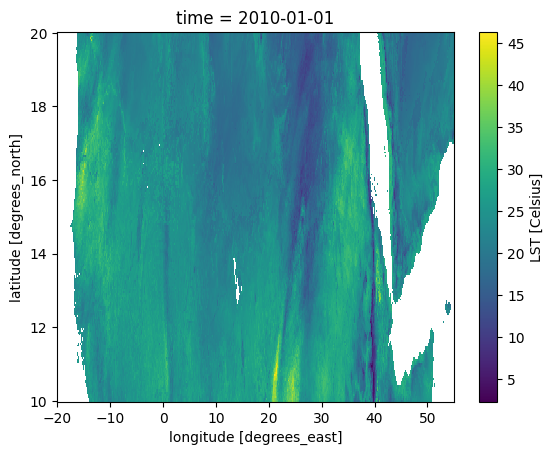

In [9]:
da_daily.LST.isel(time=0).plot()

In [10]:
lst_xarray = xr.open_dataset("/home/kzakir/dvcube/test/outputs/LST_daily_2010-01-02.nc")
lst_xarray

<xarray.Dataset> Size: 695MB
Dimensions:         (time: 96, lat: 201, lon: 1501)
Coordinates:
  * time            (time) datetime64[ns] 768B 2010-01-02 ... 2010-01-02T05:3...
  * lat             (lat) float32 804B 20.0 19.95 19.9 19.85 ... 10.1 10.05 10.0
  * lon             (lon) float32 6kB -20.0 -19.95 -19.9 ... 54.9 54.95 55.0
Data variables:
    LST             (time, lat, lon) float64 232MB ...
    crs             (time) |S1 96B ...
    quality_flag    (time, lat, lon) float64 232MB ...
    standard_error  (time, lat, lon) float64 232MB ...
Attributes: (12/29)
    date_created:               2020-11-06T12:14:43Z
    algorithm_version:          1.3.2
    base_algorithm_version:     7.15.0
    processing_level:           02
    platform:                   MSG2
    sensor:                     SEVI
    ...                         ...
    geospatial_lat_units:       degrees_north
    geospatial_lon_units:       degrees_east
    keywords:                   Earth Science, Land Surface, Land Temperature...
    keywords_vocabulary:        NASA Global change Master Directory (GCMD Sci...
    Conventions:                CF-1.6
    netcdf_version_id:          netCDF4

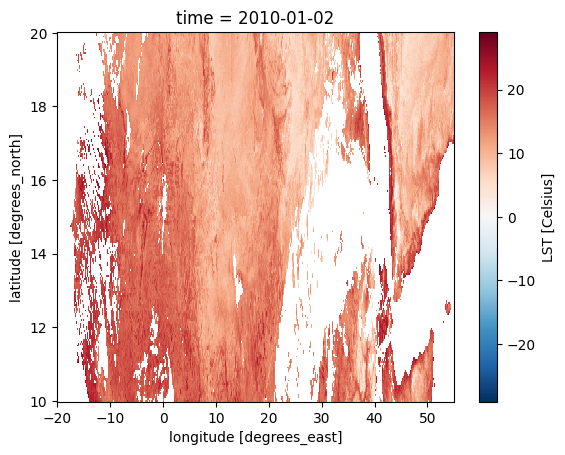

In [15]:
lst_xarray["LST"].isel(time=0).plot()

In [10]:
lst_cdo = xr.open_dataset("/data/dv-data/cdo_processed/LST_daily_15min/2010/01/merged_20100101_15min.nc")

# Fix time coordinate - convert from float (20100101.041667) to datetime64
print(f"Original time values: {lst_cdo.time.values}")
print(f"Original time dtype: {lst_cdo.time.dtype}")

# Parse float time format (YYYYMMDD.fraction_of_day)
time_floats = lst_cdo.time.values
date_part = time_floats.astype(int)  # Get YYYYMMDD part
frac_part = time_floats - date_part   # Get fractional day

# Convert YYYYMMDD to date
dates = pd.to_datetime(date_part.astype(str), format="%Y%m%d")

# Convert fraction of day to timedelta
times = pd.to_timedelta(frac_part, unit="D")

# Combine to get proper datetimes
clean_time = dates + times

# Update the time coordinate
lst_cdo = lst_cdo.assign_coords(time=("time", clean_time))

# Add CRS attributes
crs_attrs = {
    "grid_mapping_name": "latitude_longitude",
    "longitude_of_prime_meridian": 0.0,
    "semi_major_axis": 6378137.0,
    "inverse_flattening": 298.257223563
}

# Create CRS variable if it doesn't exist
if "crs" not in lst_cdo.data_vars:
    lst_cdo["crs"] = xr.DataArray(data="EPSG:4326")

# Assign CRS attributes
for key, value in crs_attrs.items():
    lst_cdo["crs"].attrs[key] = value

# Set spatial reference with rioxarray
lst_cdo = lst_cdo.rio.write_crs("EPSG:4326", inplace=True)

print(f"\n✓ Updated time coordinate:")
print(f"  New time dtype: {lst_cdo.time.dtype}")
print(f"  Time range: {lst_cdo.time.min().values} to {lst_cdo.time.max().values}")

lst_cdo

Original time values: [20100101.04166667 20100101.05208333 20100101.0625     20100101.07291667
 20100101.08333333 20100101.09375    20100101.10416667 20100101.11458333
 20100101.125      20100101.13541667 20100101.14583333 20100101.15625
 20100101.16666667 20100101.17708333 20100101.1875     20100101.19791667
 20100101.20833333 20100101.21875    20100101.22916667 20100101.23958333
 20100101.25       20100101.26041667 20100101.27083333 20100101.28125
 20100101.29166667 20100101.30208333 20100101.3125     20100101.32291667
 20100101.33333333 20100101.34375    20100101.35416667 20100101.36458333
 20100101.375      20100101.38541667 20100101.39583333 20100101.40625
 20100101.41666667 20100101.42708333 20100101.4375     20100101.44791667
 20100101.45833333 20100101.46875    20100101.47916667 20100101.48958333
 20100101.5        20100101.51041667 20100101.52083333 20100101.53125
 20100101.54166667 20100101.55208333 20100101.5625     20100101.57291667
 20100101.58333333 20100101.59375    2010

<xarray.Dataset> Size: 552MB
Dimensions:         (time: 92, lat: 200, lon: 1500)
Coordinates:
  * time            (time) datetime64[ns] 736B 2010-01-01T01:00:00.000107285 ...
  * lat             (lat) float64 2kB 10.0 10.05 10.1 10.15 ... 19.85 19.9 19.95
  * lon             (lon) float64 12kB -20.0 -19.95 -19.9 ... 54.85 54.9 54.95
    spatial_ref     int64 8B 0
Data variables:
    LST             (time, lat, lon) float64 221MB ...
    quality_flag    (time, lat, lon) float32 110MB ...
    standard_error  (time, lat, lon) float64 221MB ...
    crs             <U9 36B 'EPSG:4326'
Attributes: (12/31)
    CDI:                        Climate Data Interface version 2.0.4 (https:/...
    Conventions:                CF-1.6
    institution:                IPMA-PT
    date_created:               2020-11-06T12:13:46Z
    algorithm_version:          1.3.2
    base_algorithm_version:     7.15.0
    ...                         ...
    geospatial_lat_units:       degrees_north
    geospatial_lon_units:       degrees_east
    keywords:                   Earth Science, Land Surface, Land Temperature...
    keywords_vocabulary:        NASA Global change Master Directory (GCMD Sci...
    netcdf_version_id:          netCDF4
    CDO:                        Climate Data Operators version 2.0.4 (https:/...

In [ ]:
# Save the corrected CDO file with proper datetime
output_cdo_fixed = "/home/kzakir/dvcube/test/outputs/LST_cdo_fixed_time_2010-01-01.nc"
lst_cdo.to_netcdf(output_cdo_fixed, encoding={'LST': {'zlib': True, 'complevel': 4}})
print(f"✓ Saved corrected CDO file: {output_cdo_fixed}")

# Compare times
print(f"\nTime coordinate comparison:")
print(f"  CDO (fixed):  {lst_cdo.time.values}")


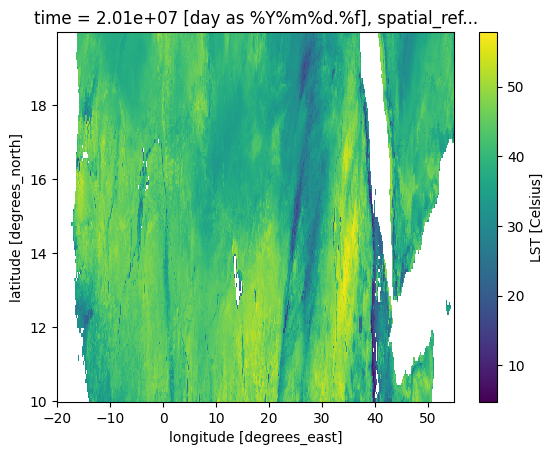

In [25]:
lst_cdo["LST"].isel(time=89).plot()

In [28]:
# find the data for 19.95, 10 and compare with xarray version 
import numpy as np
lst_cdo_point = lst_cdo["LST"].sel(lon=19.95, lat=10, method="nearest").load()
lst_xarray_point = lst_xarray["LST"].sel(lon=19.95, lat=10, method="nearest").load()

print(f"CDO point value: {float(lst_cdo_point.values) if np.ndim(lst_cdo_point.values) == 0 else lst_cdo_point.values}")
print(f"Xarray point value: {float(lst_xarray_point.values) if np.ndim(lst_xarray_point.values) == 0 else lst_xarray_point.values}")

CDO point value: [  nan   nan   nan   nan   nan   nan   nan   nan   nan   nan   nan   nan
   nan   nan   nan 12.87 14.07 14.11 14.16 14.52 14.57 14.79 15.21 15.23
 15.53 15.89 16.22 16.36 16.55 16.55 16.69 16.72 16.72 17.25 17.28 17.42
 17.57 17.59 18.3  18.6  18.77 18.87 18.96 19.34 19.95 20.01 20.37 20.68
 20.73 20.83 20.91 21.98 22.38 22.79 23.1  24.15 24.2  25.2  26.42 28.17
 29.47 30.96 32.92 33.41 33.42 35.24 36.61 37.   37.3  38.15 38.55 39.16
 39.99 40.07 41.95 42.33 42.33 42.68 43.68 43.77 44.28 44.9  45.32 45.71
 45.96 46.11 46.51 46.66 46.76 46.96 47.17 47.56]
Xarray point value: [16.33 15.97 15.97 16.27 15.47 15.35 15.3  15.51 15.6  15.01 14.39 14.39
 14.05 14.   13.86 13.14 13.71 13.59 13.28 13.63 13.36 13.7  15.44 17.03
 19.51 21.11 23.19 25.64 27.04 28.66 30.36 32.32 33.77 35.6  37.66 38.83
 40.47 41.5  42.79 44.45 45.32 45.74 46.42 47.54 47.47 48.2  47.84 47.96
 48.6  48.01 47.51 46.8  45.91 45.43 44.29 43.41 42.27 41.24 39.8  38.3
 36.72 34.72 32.97 30.47 29.21 26.95 2

In [14]:
files = glob.glob("/data/dv-data/raw/lst_new/2010/01/01/*.nc")
da = xr.open_mfdataset(files, 
                       engine="h5netcdf",
                       decode_times=True,
                       combine="by_coords",
                       parallel=False,
                       chunks=None, 
                       coords="minimal",
                       data_vars="minimal",
                       compat="override",
                       )

# Clean time coordinate: decode CF times and filter out invalid dates
import pandas as pd

# Decode times if not already decoded
if da.time.dtype != 'datetime64[ns]':
    da['time'] = pd.to_datetime(da.time.values)

# Filter out dates that are not 2010-01-01 (removes 2009-12-31 artifacts)
valid_mask = da.time.dt.date == pd.Timestamp("2010-01-01").date()
da = da.isel(time=valid_mask)

# Round to 15min intervals for CF times
da['time'] = pd.to_datetime(da.time.values).round("15min")

# Set proper time encoding
da['time'].attrs = {}
da['time'].encoding = {
    "units": "seconds since 2010-01-01 00:00:00", 
    "calendar": "proleptic_gregorian"
}

print(da.time.min().values, da.time.max().values)
print(da.time.values)
print(f"Total timesteps after cleaning: {len(da.time)}")

2010-01-01T01:00:00.000000000 2010-01-01T23:45:00.000000000
['2010-01-01T01:00:00.000000000' '2010-01-01T01:15:00.000000000'
 '2010-01-01T01:30:00.000000000' '2010-01-01T01:45:00.000000000'
 '2010-01-01T02:00:00.000000000' '2010-01-01T02:15:00.000000000'
 '2010-01-01T02:30:00.000000000' '2010-01-01T02:45:00.000000000'
 '2010-01-01T03:00:00.000000000' '2010-01-01T03:15:00.000000000'
 '2010-01-01T03:30:00.000000000' '2010-01-01T03:45:00.000000000'
 '2010-01-01T04:00:00.000000000' '2010-01-01T04:15:00.000000000'
 '2010-01-01T04:30:00.000000000' '2010-01-01T04:45:00.000000000'
 '2010-01-01T05:00:00.000000000' '2010-01-01T05:15:00.000000000'
 '2010-01-01T05:30:00.000000000' '2010-01-01T05:45:00.000000000'
 '2010-01-01T06:00:00.000000000' '2010-01-01T06:15:00.000000000'
 '2010-01-01T06:30:00.000000000' '2010-01-01T06:45:00.000000000'
 '2010-01-01T07:00:00.000000000' '2010-01-01T07:15:00.000000000'
 '2010-01-01T07:30:00.000000000' '2010-01-01T07:45:00.000000000'
 '2010-01-01T08:00:00.00000000

In [ ]:
# read all the files in this folder /data/dv-data/raw/lst_new/2010/01/01
# lstpath = "/data/dv-data/cdo_processed/LST"
# files = sorted(glob.glob(f"{lstpath}/*.nc"))
# print(f"Found {len(files)} files in {lstpath}")
# assert len(files) > 0, "No .nc files found"
# # open them with xarray
# # ds = xr.open_mfdataset(files, combine="nested", concat_dim="time")
#open this zarr /data/dv-data/zarr_new/lst_sahel.zarr

ds = xr.open_dataset("/data/dv-data/raw/lst_new/2010/01/01/NETCDF4_LSASAF_MSG_LST_MSG-Disk_201001010100.nc", engine="h5netcdf")
# raw = ds ["time"].values
# date_part = raw.astype(int)
# frac_part = raw - date_part

# dates = pd.to_datetime(date_part.astype(str), format="%Y%m%d")
# times = pd.to_timedelta(frac_part, unit="D")
# clean_time = dates + times
# ds = ds.assign_coords(time=("time", clean_time))
# ds

# check the saptial resolution
print(f"Latitude resolution: {ds.lat.diff('lat').mean().values:.4f} degrees")
print(f"Longitude resolution: {ds.lon.diff('lon').mean().values:.4f} degrees")



<xarray.Dataset> Size: 552MB
Dimensions:         (time: 92, lat: 200, lon: 1500)
Coordinates:
  * time            (time) datetime64[ns] 736B 2010-01-01T01:00:00.000107285 ...
  * lat             (lat) float64 2kB 10.0 10.05 10.1 10.15 ... 19.85 19.9 19.95
  * lon             (lon) float64 12kB -20.0 -19.95 -19.9 ... 54.85 54.9 54.95
Data variables:
    LST             (time, lat, lon) float64 221MB ...
    quality_flag    (time, lat, lon) float32 110MB ...
    standard_error  (time, lat, lon) float64 221MB ...
Attributes: (12/31)
    CDI:                        Climate Data Interface version 2.0.4 (https:/...
    Conventions:                CF-1.6
    institution:                IPMA-PT
    date_created:               2020-11-06T12:13:46Z
    algorithm_version:          1.3.2
    base_algorithm_version:     7.15.0
    ...                         ...
    geospatial_lat_units:       degrees_north
    geospatial_lon_units:       degrees_east
    keywords:                   Earth Science, Land Surface, Land Temperature...
    keywords_vocabulary:        NASA Global change Master Directory (GCMD Sci...
    netcdf_version_id:          netCDF4
    CDO:                        Climate Data Operators version 2.0.4 (https:/...

In [27]:
# check the bounding box of the data
print("Bounding box:")
print(f"  - lat: {ds.lat.min().values:.2f} to {ds.lat.max().values:.2f}")
print(f"  - lon: {ds.lon.min().values:.2f} to {ds.lon.max().values:.2f}")
print(f"  - time: {ds.time.min().values} to {ds.time.max().values}")    

Bounding box:
  - lat: 10.00 to 19.95
  - lon: -20.00 to 54.95
  - time: 2010-01-01T01:00:00.000107285 to 2010-01-01T23:44:59.999892714


In [12]:
def aggregate_to_daily(ds:xr.Dataset) -> xr.Dataset:

    daily = xr.Dataset(
        {
            "LST_mean": ds["LST"].resample(time="1D").mean(),
            "LST_min": ds["LST"].resample(time="1D").min(),
            "LST_max": ds["LST"].resample(time="1D").max(),
            "quality_flag_max": ds["quality_flag"].resample(time="1D").max(),
            "standard_error_mean": ds["standard_error"].resample(time="1D").mean()
            }

    )
    return daily



In [13]:
daily = aggregate_to_daily(lst_xarray)

ValueError: Index must be monotonic for resampling

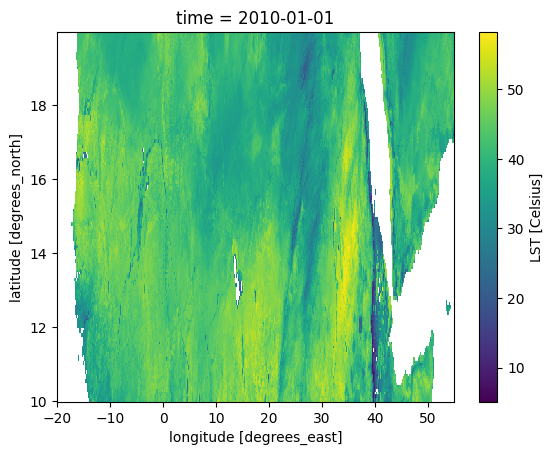

In [33]:
daily["LST_max"].plot()